# Research of advertisements for the sale of apartments

We have at our disposal data from the Yandex.Real Estate service - an archive of advertisements for the sale of apartments in St. Petersburg and neighboring settlements for several years. You need to learn how to determine the market value of real estate. Our job is to set the parameters. This will allow you to build an automated system: it will track anomalies and fraudulent activity.

For each apartment for sale, two types of data are available. The first ones are entered by the user, the second ones are obtained automatically based on cartographic data. For example, the distance to the center, airport, nearest park and pond.

### Let's open the data file and study the general information.

In [3]:
import pandas as pd
import numpy as np

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23699 non-null  int64         
 1   last_price            23699 non-null  float64       
 2   total_area            23699 non-null  float64       
 3   first_day_exposition  23699 non-null  datetime64[ns]
 4   rooms                 23699 non-null  int64         
 5   ceiling_height        14504 non-null  float64       
 6   floors_total          23613 non-null  float64       
 7   living_area           21796 non-null  float64       
 8   floor                 23699 non-null  int64         
 9   is_apartment          2775 non-null   object        
 10  studio                23699 non-null  bool          
 11  open_plan             23699 non-null  bool          
 12  kitchen_area          21421 non-null  float64       
 13  balcony         

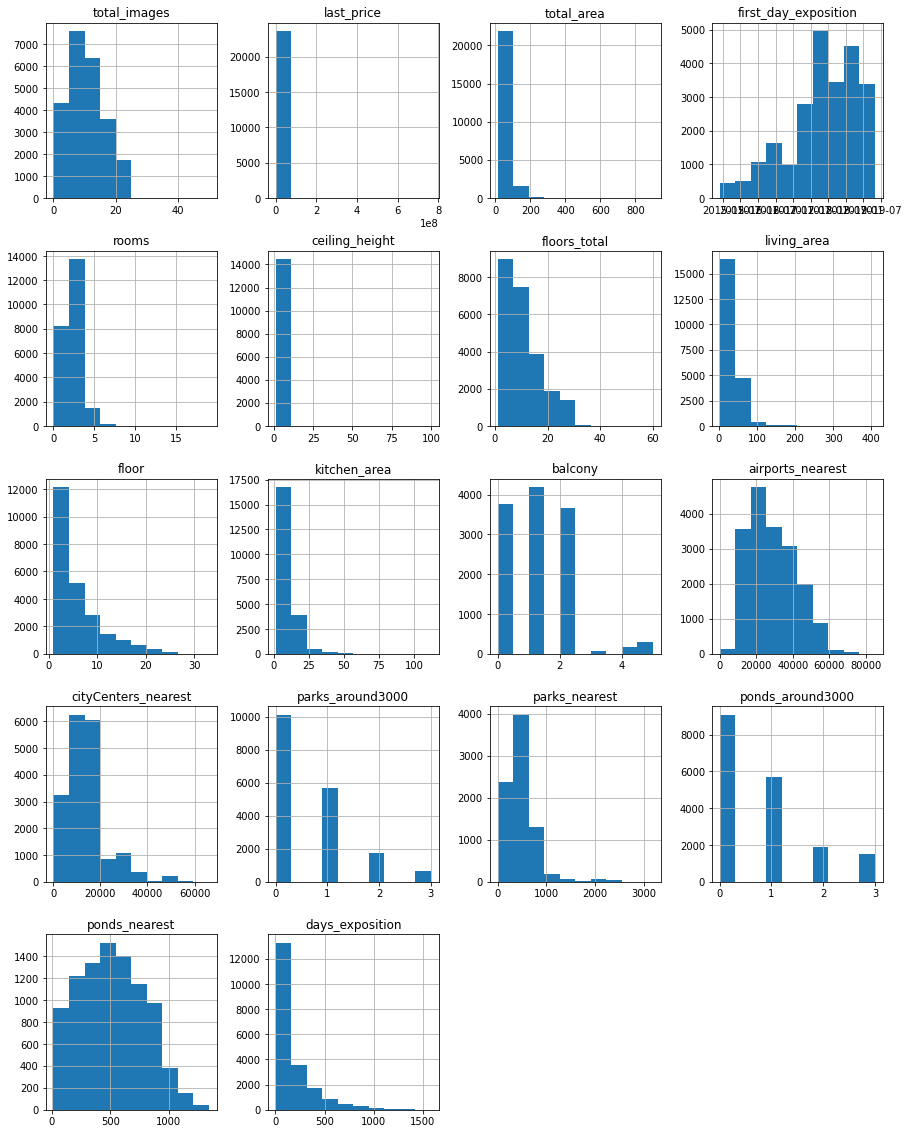

In [17]:
data = pd.read_csv('/datasets/real_estate_data.csv', sep='\t', parse_dates=['first_day_exposition'])

data.info()

data.hist(figsize=(15, 20));

In [18]:
display(data)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.00,2019-03-07,3,2.70,16.0,51.0,8,NaN,...,25.00,NaN,Sankt-Peterburg,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.40,2018-12-04,1,NaN,11.0,18.6,1,NaN,...,11.00,2.0,poselok Shushary,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.00,2015-08-20,2,NaN,5.0,34.3,4,NaN,...,8.30,0.0,Sankt-Peterburg,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.00,2015-07-24,3,NaN,14.0,NaN,9,NaN,...,NaN,0.0,Sankt-Peterburg,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.00,2018-06-19,2,3.03,14.0,32.0,13,NaN,...,41.00,NaN,Sankt-Peterburg,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23694,9,9700000.0,133.81,2017-03-21,3,3.70,5.0,73.3,3,NaN,...,13.83,NaN,Sankt-Peterburg,24665.0,4232.0,1.0,796.0,3.0,381.0,NaN
23695,14,3100000.0,59.00,2018-01-15,3,NaN,5.0,38.0,4,NaN,...,8.50,NaN,Tosno,NaN,NaN,NaN,NaN,NaN,NaN,45.0
23696,18,2500000.0,56.70,2018-02-11,2,NaN,3.0,29.7,1,NaN,...,NaN,NaN,selo Rozhdestveno,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23697,13,11475000.0,76.75,2017-03-28,2,3.00,17.0,NaN,12,NaN,...,23.30,2.0,Sankt-Peterburg,39140.0,10364.0,2.0,173.0,3.0,196.0,602.0


Upon initial inspection of the data, you can notice many omissions, a fairly large spread of values ​​in some columns, as well as obvious errors in the data type for some columns, for example 'balcony' - the number of balconies is of float type.

### Data preprocessing

In [19]:
print(data.isna().sum())

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9195
floors_total               86
living_area              1903
floor                       0
is_apartment            20924
studio                      0
open_plan                   0
kitchen_area             2278
balcony                 11519
locality_name              49
airports_nearest         5542
cityCenters_nearest      5519
parks_around3000         5518
parks_nearest           15620
ponds_around3000         5518
ponds_nearest           14589
days_exposition          3181
dtype: int64


The "floors_total" column cannot be populated based on other data. You can try to fill out the “living_area” column and the “kitchen_area” column by grouping apartments by area. The "balcony" column can be filled in with 0, if the owner did not indicate them, then most likely not. The 'ceiling_height' column can be filled with median values ​​since most of the data in this column is in a small range.

In [20]:
data['ceiling_height'] = data['ceiling_height'].fillna(data['ceiling_height'].median())
data['kitchen_area'] = data['kitchen_area'].fillna(data.groupby('total_area')['kitchen_area'].transform('median'))
data['living_area'] = data['living_area'].fillna(data.groupby('total_area')['living_area'].transform('median'))
data['balcony'] = data['balcony'].fillna(0)

Blanks in the "is_apartment" column can be filled with False, since if the owner did not indicate that this is an apartment, then it is not them. 
The "locality_name" column cannot be populated based on other data.

In [21]:
data['is_apartment'] = data['is_apartment'].fillna(False)
data['locality_name'] = data['locality_name'].fillna("")

The gaps in the "airports_nearest" column could be filled with median values ​​by locality. Before filling there were 5542 gaps, after filling 5386. It turns out that the remaining 5386 gaps can no longer be filled. You cannot fill in data in kitchen_area based on others. The "cityCenters_nearest" column is similar to the "airports_nearest" column.

In [22]:
median_airports_nearest_table = data.groupby('locality_name')['airports_nearest'].transform('median')
data['airports_nearest'] = data['airports_nearest'].fillna(median_airports_nearest_table)
#data['kitchen_area'] = data['kitchen_area'].fillna(data['total_area'] - data['living_area'])
data['cityCenters_nearest'] = data['cityCenters_nearest'].fillna(data.groupby('locality_name')['cityCenters_nearest'].transform('median'))






You can fill in the gaps in the “parks_around3000” and “ponds_around3000” columns with 0, since if the owner did not indicate it, then they don’t exist, but you won’t be able to fill in the gaps in the “parks_nearest” and “ponds_nearest” columns based on other data. The "days_exposition" gaps cannot be filled in based on other data.

In [23]:
my_iter = iter(data.index.values)
# Check cases where the number of parks is missing but the park distance is present.
for i in range(len(data['parks_around3000'])):
    index = next(my_iter)
    if pd.isna(data.loc[index, 'parks_around3000']):
        if not pd.isna(data.loc[index, 'parks_nearest']):
            print(data.loc[index, 'parks_nearest'])

data['parks_around3000'] = data['parks_around3000'].fillna(0)   
    

data['ponds_around3000'] = data['ponds_around3000'].fillna(0)    

In [24]:
print(data.isna().sum())

data.info()

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height              0
floors_total               86
living_area               143
floor                       0
is_apartment                0
studio                      0
open_plan                   0
kitchen_area              205
balcony                     0
locality_name               0
airports_nearest         5386
cityCenters_nearest      5386
parks_around3000            0
parks_nearest           15620
ponds_around3000            0
ponds_nearest           14589
days_exposition          3181
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23699 non-null  int64         
 1   last_price            23699 non-null  f

floors_total last_price balcony parks_around3000 ponds_around3000 days_exposition - all these slabs were converted to an integer type, since they contain the number of floors, price, number of balconies, number of parks, number of ponds and number of days, respectively, and cannot contain non-integer numbers except for price, however, all data in this column is integer numbers, so it is also converted to int.

In [25]:
data['floors_total'] = data['floors_total'].astype('Int64')
data['last_price'] = data['last_price'].astype('Int64')
data['balcony'] = data['balcony'].astype('Int64')
data['parks_around3000'] = data['parks_around3000'].astype('Int64')
data['ponds_around3000'] = data['ponds_around3000'].astype('Int64')
# data['days_exposition'] = data['days_exposition'].astype('Int64')
data['days_exposition'] = np.floor(pd.to_numeric(data['days_exposition'], errors='coerce')).astype('Int64')

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23699 non-null  int64         
 1   last_price            23699 non-null  Int64         
 2   total_area            23699 non-null  float64       
 3   first_day_exposition  23699 non-null  datetime64[ns]
 4   rooms                 23699 non-null  int64         
 5   ceiling_height        23699 non-null  float64       
 6   floors_total          23613 non-null  Int64         
 7   living_area           23556 non-null  float64       
 8   floor                 23699 non-null  int64         
 9   is_apartment          23699 non-null  bool          
 10  studio                23699 non-null  bool          
 11  open_plan             23699 non-null  bool          
 12  kitchen_area          23494 non-null  float64       
 13  balcony         

To avoid any implicit duplications, it was decided to remove all prefixes and leave only the names. If you need to have prefixes in the future, they can be distributed using prepared prefixes so that there are no duplicates.

In [26]:
def getting_last_word(prefix_and_name):
    last_word = prefix_and_name.split(' ')
    if last_word[-1] == '\u043a\u0438\u043b\u043e\u043c\u0435\u0442\u0440':
        return 'Platform 69th kilometer'
    return last_word[-1]
    

data['locality_name'] = data['locality_name'].apply(getting_last_word)
tmp = data.query('locality_name == ""')
tmp

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
1097,3,8600000,81.70,2016-04-15,3,3.55,5,50.80,2,False,...,8.80,0,,23478.0,4258.0,0,NaN,0,NaN,147
2033,6,5398000,80.00,2017-05-30,3,2.65,4,42.60,2,False,...,18.60,0,,22041.0,8943.0,0,NaN,0,NaN,34
2603,20,3351765,42.70,2015-09-20,1,2.65,24,15.60,3,False,...,10.70,0,,22041.0,17369.0,0,NaN,1,374.0,276
2632,2,5130593,62.40,2015-10-11,2,2.65,24,33.10,21,False,...,8.20,0,,22041.0,17369.0,0,NaN,1,374.0,256
3574,10,4200000,46.50,2016-05-28,2,2.65,5,30.80,5,False,...,6.50,0,,27419.0,8127.0,0,NaN,1,603.0,45
4151,17,17600000,89.50,2014-12-09,2,3.00,8,39.62,7,False,...,13.38,0,,25054.0,3902.0,1,485.0,3,722.0,869
4189,7,9200000,80.00,2015-12-10,3,4.00,4,52.30,3,False,...,10.40,0,,21774.0,3039.0,1,690.0,1,953.0,223
4670,1,5500000,83.00,2015-08-14,3,2.65,7,52.00,6,False,...,11.00,0,,26534.0,5382.0,1,446.0,1,376.0,350
5343,19,13540000,85.50,2016-01-20,3,2.65,7,59.10,5,False,...,8.30,4,,10556.0,9538.0,1,67.0,0,NaN,303
5707,7,3700000,30.00,2016-04-29,1,2.65,24,20.00,23,False,...,6.00,0,,21460.0,16788.0,0,NaN,1,170.0,49


You can notice ceiling heights such as 25, 26, etc. Most likely, the owner who entered the data could have made a mistake by one character, which is why the ceilings were so huge. There are also ceilings with a height of 1, 1.2 or 8. In this case, it is better to replace them with gaps, since it is impossible to make a mistake in the sign here, and there are no ceilings with a height of 1 meter or 8, or there are practically only a few of them.

In [27]:
data['ceiling_height'] = data['ceiling_height'].where(data['ceiling_height'] < 18, np.round(data['ceiling_height']/10, 1))
data['ceiling_height'] = data['ceiling_height'].where((data['ceiling_height'] > 1.8) & (data['ceiling_height'] < 6), np.nan)

Each column was checked for unique values. Borders and outliers were corrected where required.

There were apartments that cost almost 1 billion rubles, and accordingly they had to be removed. There were also data similar to 0 meters to the nearest airport, which is also not true and an error was made when creating an advertisement for sale. There were also kitchens with an area of ​​1 or 2 meters, which again is incorrect and impossible data. There were apartments with 19 rooms and an area of ​​900 square meters, that is, almost a kilometer, and they also had to be processed.

In [28]:
data['last_price'] = data['last_price'].where((1000000 < data['last_price']) & (data['last_price'] < 200000000), np.nan)
data['kitchen_area'] = data['kitchen_area'].where(data['kitchen_area'] > 3.5, np.nan)
data['airports_nearest'] = data['airports_nearest'].where(data['airports_nearest'] > 0, np.nan)
data['parks_nearest'] = data['parks_nearest'].where(data['parks_nearest'] > 10, np.nan)

data['rooms'] = data['rooms'].where(data['rooms'] < 15, np.nan)

data['rooms'] = data['rooms'].where(data['rooms'] > 0, np.nan)

data['total_area'] = data['total_area'].where(data['total_area'] < 300, np.nan)

data['rooms'] = data['rooms'].astype('Int64')
# display(data['rooms'].sort_values().unique())
# print(data['total_area'].sort_values().unique())

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23699 non-null  int64         
 1   last_price            23445 non-null  Int64         
 2   total_area            23636 non-null  float64       
 3   first_day_exposition  23699 non-null  datetime64[ns]
 4   rooms                 23499 non-null  Int64         
 5   ceiling_height        23688 non-null  float64       
 6   floors_total          23613 non-null  Int64         
 7   living_area           23556 non-null  float64       
 8   floor                 23699 non-null  int64         
 9   is_apartment          23699 non-null  bool          
 10  studio                23699 non-null  bool          
 11  open_plan             23699 non-null  bool          
 12  kitchen_area          23462 non-null  float64       
 13  balcony         

### Let's count and add new columns to the table

In [29]:
data['price_per_1_sq_meter'] = data['last_price'] / data['total_area']
# If needed, map weekday numbers 0-6 to weekday names.
data['day_of_the_week'] = data['first_day_exposition'].dt.weekday
data['month'] = data['first_day_exposition'].dt.month
data['year'] = data['first_day_exposition'].dt.year

def first_and_last_floor(row):
    if not pd.isnull(row['floors_total']) and row['floor'] == row['floors_total']:
        return 'Last'
    if row['floor'] == 1:
        return 'First'
    return 'Other'
data['first_last_etc_floor'] = data.apply(first_and_last_floor, axis=1)


data['distance_to_center_in_km'] = round(data['cityCenters_nearest'] / 1000)
display(data.head())

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,price_per_1_sq_meter,day_of_the_week,month,year,first_last_etc_floor,distance_to_center_in_km
0,20,13000000,108.0,2019-03-07,3,2.70,16,51.0,8,False,...,482.0,2,755.0,<NA>,120370.37037,3,3,2019,Other,16.0
1,7,3350000,40.4,2018-12-04,1,2.65,11,18.6,1,False,...,NaN,0,NaN,81,82920.792079,1,12,2018,First,19.0
2,10,5196000,56.0,2015-08-20,2,2.65,5,34.3,4,False,...,90.0,2,574.0,558,92785.714286,3,8,2015,Other,14.0
3,0,64900000,159.0,2015-07-24,3,2.65,14,95.0,9,False,...,84.0,3,234.0,424,408176.100629,4,7,2015,Other,7.0
4,2,10000000,100.0,2018-06-19,2,3.03,14,32.0,13,False,...,112.0,1,48.0,121,100000.0,1,6,2018,Other,8.0


### Let's conduct exploratory data analysis

You can notice that most apartments have a total area in the range of 12-100 square meters, the peak total area of ​​an apartment is around 45 meters.

<AxesSubplot:ylabel='Frequency'>

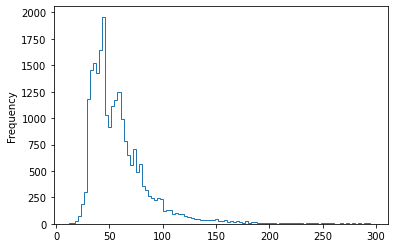

In [30]:
data['total_area'].plot(kind='hist', y='total_area', histtype="step", bins=100)

There are several peaks of living area: 18 meters, 30 meters, 45 meters.

<AxesSubplot:ylabel='Frequency'>

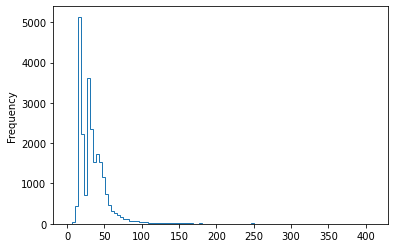

In [31]:
data['living_area'].plot(kind='hist', y='living_area', histtype="step", bins=100)

There is a micro-jump at 0 meters, this is typical for studios, and the peak is around 10 meters.

<AxesSubplot:ylabel='Frequency'>

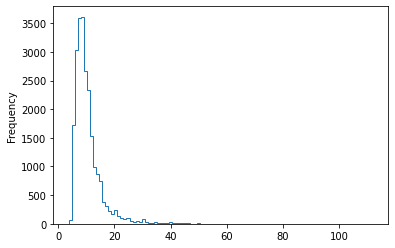

In [32]:
data['kitchen_area'].plot(kind='hist', y='kitchen_area', histtype="step", bins=100)

Let's convert rubles to millions for clarity. We will see that the peak selling price is in the region of 5 million rubles.

<AxesSubplot:ylabel='Frequency'>

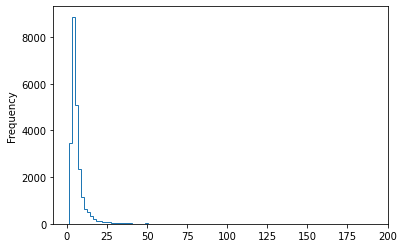

In [33]:
data['last_price_in_mln'] = data['last_price'] / 1000000
data['last_price_in_mln'].plot(kind='hist', y='last_price_in_mln', histtype="step", bins=100)

You will notice that the majority of apartments are one-room, followed by two-room, and so on. The more rooms in the apartment, the fewer such apartments.

<AxesSubplot:ylabel='Frequency'>

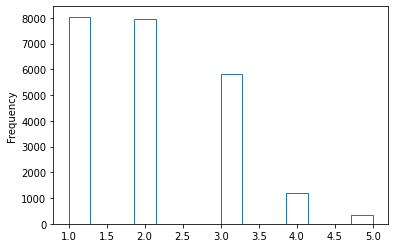

In [34]:
data['rooms'].plot(kind='hist', y='rooms', histtype="step", bins=data['rooms'].max(), range=(1, 5))


You will notice that most of the apartments for sale are located on the 3rd floor. And further, the higher the floor, the fewer such apartments.

<AxesSubplot:ylabel='Frequency'>

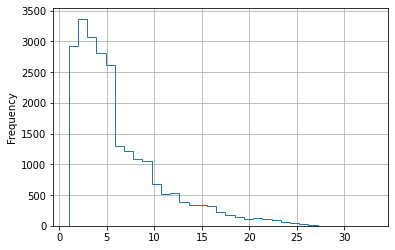

In [35]:
data['floor'].plot(kind='hist', y='floor', histtype="step", bins=33, grid=True)


Most apartments are located neither on the first nor on the last floor. But this is already understandable, because in the houses the first and last are only 2 floors out of all.

<AxesSubplot:>

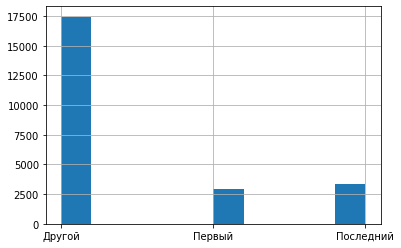

In [36]:
data['first_last_etc_floor'].hist()

You can notice that most of the advertisements are displayed in 5 floors or 9 floors, which corresponds to reality and is very truthful.

<AxesSubplot:ylabel='Frequency'>

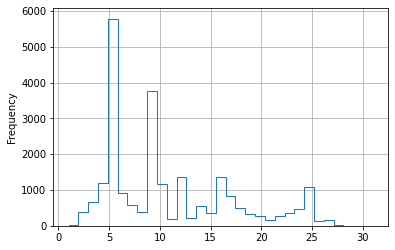

In [37]:
data['floors_total'].plot(kind='hist', y='floors_total', histtype="step", bins=31, grid=True, range=(1, 31))


Most apartments are located in the area 15 km from the center. If you are further 15 km from the center, the fewer such apartments.

<AxesSubplot:>

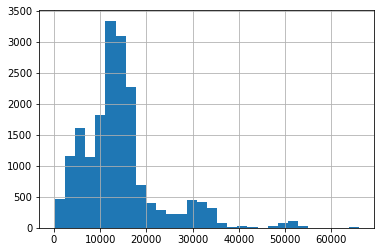

In [38]:
data['cityCenters_nearest'].hist(bins=30)

Most apartments are located within 20 km from the nearest airport. However, there are many peaks, for example at 25km or 35km. Since the data is taken from a huge number of villages, towns and cities, they can all be chaotically located around the airport, which is why there are so many peaks.

<AxesSubplot:>

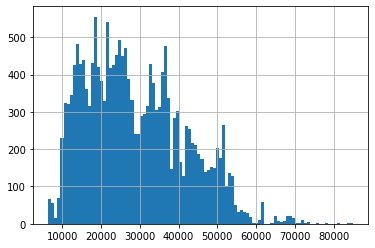

In [39]:
data['airports_nearest'].hist(bins=100)

Most of the apartments are located within 500m from the nearest park, which we can happily say is within walking distance.

<AxesSubplot:>

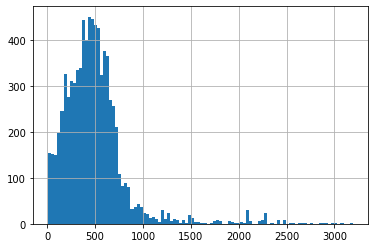

In [40]:
data['parks_nearest'].hist(bins=100)

<AxesSubplot:ylabel='Frequency'>

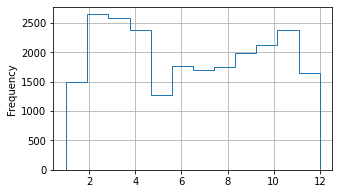

In [41]:
data['month'].plot(kind='hist', y='month', histtype="step", bins=12, grid=True, figsize = (5,3))



Most often, apartments were exhibited on March 13th. In general, there are many peaks by day and are unlikely to depend on any external data from our dataframe.

<AxesSubplot:ylabel='Frequency'>

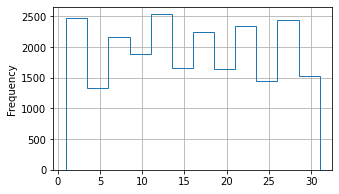

In [42]:
data['day'] = pd.DatetimeIndex(data['first_day_exposition']).day
data['day'].plot(kind='hist', y='day', histtype="step", bins=12, grid=True, figsize = (5,3))

It is not difficult to notice that there is one huge peak in ceiling height - around 2.75 meters. The higher the ceiling height, the fewer such apartments.

<AxesSubplot:ylabel='Frequency'>

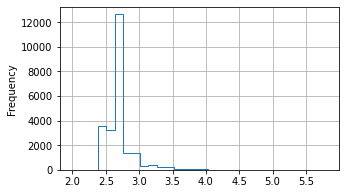

In [43]:
data['ceiling_height'].plot(kind='hist', y='ceiling_height', histtype="step", bins=30, grid=True, figsize = (5,3))

The mean and median differ by almost two times. This is because there are sales that occurred both in 1 day and in 1580 days. We will consider sales that lasted more than a year to be unusually long, and sales that lasted more than a year to be unusually fast - less than two weeks.

count    20518.000000
mean       180.888634
std        219.727988
min          1.000000
25%         45.000000
50%         95.000000
75%        232.000000
max       1580.000000
Name: days_exposition, dtype: float64

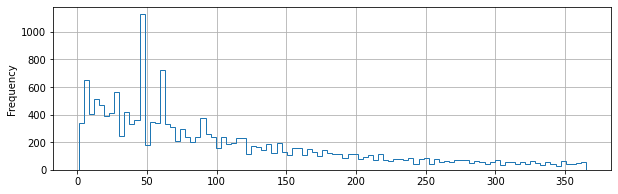

In [44]:
data['days_exposition'].plot(kind='hist', y='days_exposition', histtype="step", bins=100, grid=True, figsize = (10,3), range=(1, 365))



data['days_exposition'].describe()

The graph clearly shows the trend that as the area increases, the cost of the apartment also increases.

<AxesSubplot:xlabel='total_area'>

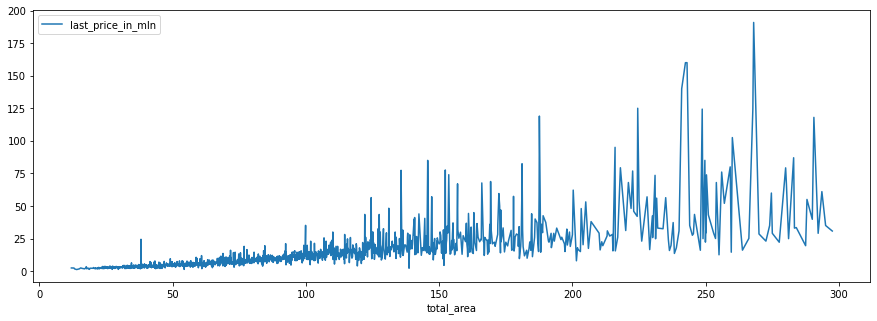

In [58]:
data.pivot_table(index='total_area', values='last_price_in_mln', aggfunc='median').plot(figsize=(15, 5))

<AxesSubplot:xlabel='total_area', ylabel='last_price_in_mln'>

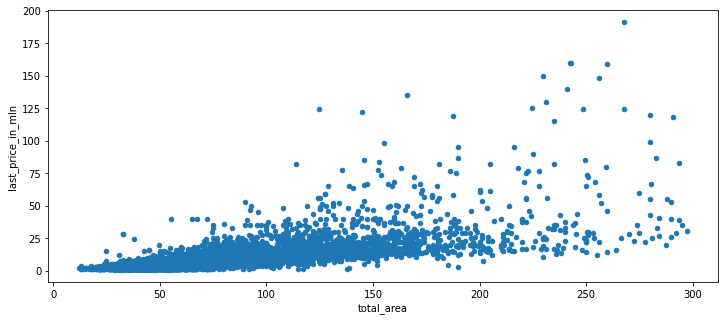

In [46]:
data.plot(x='total_area', y='last_price_in_mln', kind='scatter', figsize=(12, 5))


Just like with the total area: the larger the living space, the higher the price.

<AxesSubplot:xlabel='living_area'>

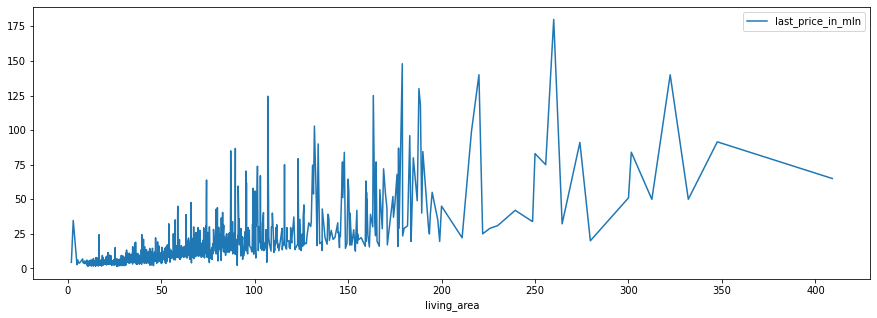

In [47]:
data.pivot_table(index='living_area', values='last_price_in_mln', aggfunc='median').plot(figsize=(15, 5))

Similar to the two previous parameters.

<AxesSubplot:xlabel='kitchen_area'>

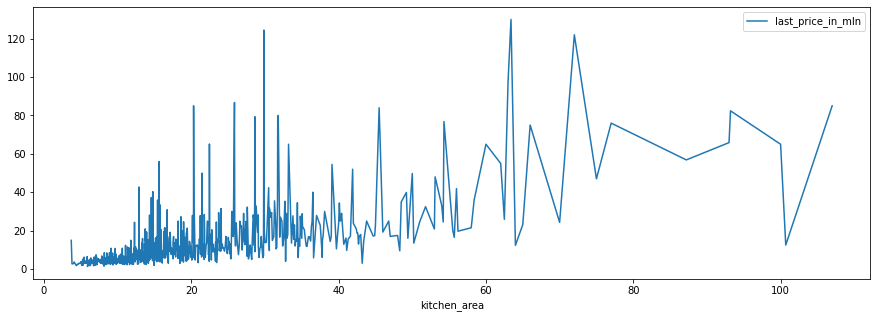

In [48]:
data.pivot_table(index='kitchen_area', values='last_price_in_mln', aggfunc='median').plot(figsize=(15, 5))

Again, the pattern is clearly visible: the more rooms, the higher the cost.

<AxesSubplot:xlabel='rooms'>

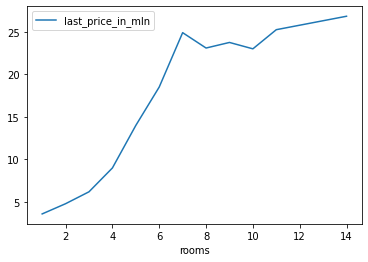

In [49]:
data.pivot_table(index='rooms', values='last_price_in_mln', aggfunc='median').plot()

The cheapest apartments are on the ground floor, followed by the top floor. Usually, people prefer to buy apartments not on the 1st and not on the top floor, but something in between, which is why the price of apartments between the first and last floor is higher.

<AxesSubplot:xlabel='first_last_etc_floor'>

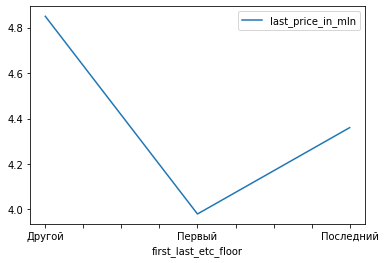

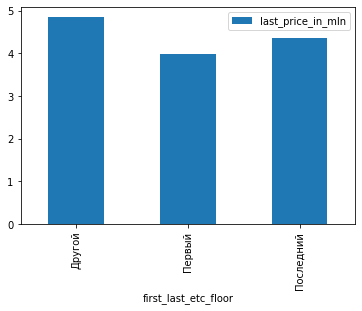

In [50]:
data.pivot_table(index='first_last_etc_floor', values='last_price_in_mln', aggfunc='median').plot()
data.pivot_table(index='first_last_etc_floor', values='last_price_in_mln', aggfunc='median').plot(kind='bar')

The price does not depend in any way on the date of placement. There are isolated outliers, but they occur because apartments are put up for sale that are too expensive, and there is no growth in the trend.

You'll notice that the closer you get to the weekend, the lower the price, but actually if you look at the range it's quite low to indicate that it really depends on the day of the week.

<AxesSubplot:xlabel='day_of_the_week'>

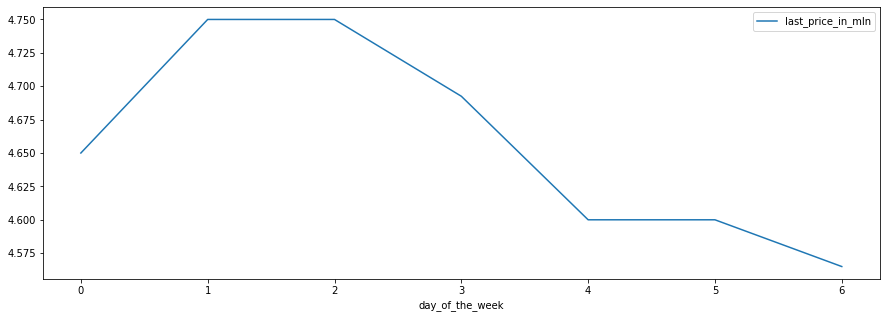

In [51]:
data.pivot_table(index='day_of_the_week', values='last_price_in_mln', aggfunc='median').plot(figsize=(15, 5))

The cheapest apartments were offered in June, but again, looking at the price range, it is impossible to say for sure that this is precisely because of the month of exhibition.

<AxesSubplot:xlabel='month'>

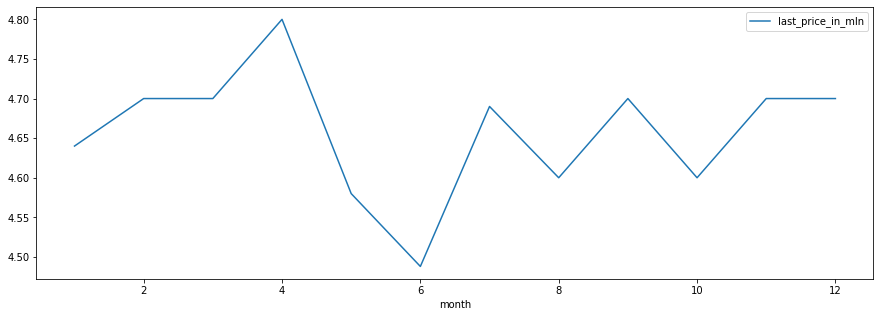

In [52]:
data.pivot_table(index='month', values='last_price_in_mln', aggfunc='median').plot(figsize=(15, 5))


But here we can say for sure that apartment prices in 2014 were an order of magnitude higher than in all subsequent years.

<AxesSubplot:xlabel='year'>

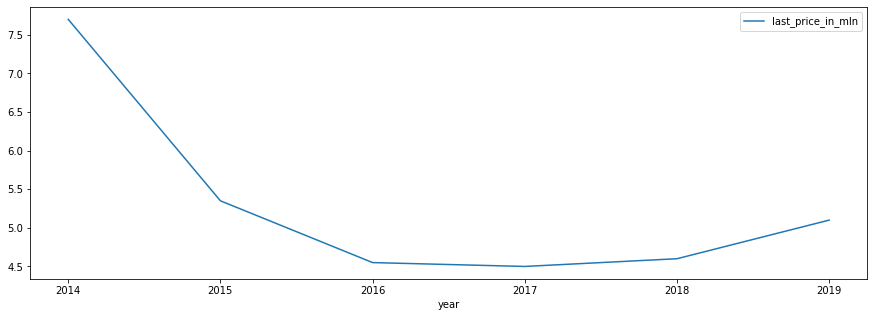

In [53]:
data.pivot_table(index='year', values='last_price_in_mln', aggfunc='median').plot(figsize=(15, 5))


In [54]:
print(data[['last_price', 'total_area', 'living_area', 'rooms']].corr())

             last_price  total_area  living_area     rooms
last_price     1.000000    0.715991     0.662486  0.435592
total_area     0.715991    1.000000     0.936950  0.784220
living_area    0.662486    0.936950     1.000000  0.841679
rooms          0.435592    0.784220     0.841679  1.000000


In [55]:
# Reviewer code
data['last_price'].astype('float64').corr(data['total_area'].astype('float64'))

0.7159912864727559

In [56]:
df = data.pivot_table(index='locality_name', values='price_per_1_sq_meter', aggfunc=['count','mean'])
df.columns = ['count', 'mean_of_price_per_1_sq_meter']
df = df.sort_values(by='count', ascending=False)
display(df.head(10))
df = df.head(10)



maxx = df['mean_of_price_per_1_sq_meter'].max()
minn = df['mean_of_price_per_1_sq_meter'].min()
display(df.query('mean_of_price_per_1_sq_meter == @maxx'))
display(df.query('mean_of_price_per_1_sq_meter == @minn'))



,count,mean_of_price_per_1_sq_meter
locality_name,,
Sankt-Peterburg,15711,114136.518737
Murino,590,86087.51205
Kudrovo,472,95324.930544
Shushary,440,78677.364217
Vsevolozhsk,397,68719.287383
Pushkin,369,103130.851744
Kolpino,338,75333.295801
Pargolovo,327,90175.913458
Gatchina,306,68935.194838


,count,mean_of_price_per_1_sq_meter
locality_name,,
Sankt-Peterburg,15711,114136.518737


,count,mean_of_price_per_1_sq_meter
locality_name,,
Vyborg,233,58685.669032


You can notice that a sharp decline is observed at 3 km from the center. And in general - the further from the center, the cheaper, and in comparison with 0-3 km the difference will be colossal. It can be assumed that the city center ends at 3 km.

In [57]:
saint_petersburg = '\u0421\u0430\u043d\u043a\u0442-\u041f\u0435\u0442\u0435\u0440\u0431\u0443\u0440\u0433'
my_data = data.query('locality_name == @saint_petersburg').pivot_table(index='distance_to_center_in_km', values='last_price')
print(my_data.sort_values(by='last_price', ascending=False))
data.query('locality_name == @saint_petersburg').pivot_table(index='distance_to_center_in_km', values='last_price_in_mln').plot()

### General conclusion

An analysis of data on advertisements for the sale of apartments was carried out. There were quite a few gaps in the data, which were filled only partially by relying on logical thinking to fill the gaps, for example in the 'balcony' column, or by using other data to fill, for example 'airport_nearest', for which it was necessary to group the data and find the median value by 'locality_name' to fill the gaps, but it was almost impossible to fill such columns completely. Errors were identified in the column types, and the column types were manually changed to more correct and more suitable ones. Many important and interesting dependencies were found, for example: The cheapest apartments are located on the ground floor, and the most advertisements are displayed in 5- and 9-story buildings. The good news is that most apartments are located 500 meters from the nearest park. An important conclusion will be the fact that there is a tendency for the price of an apartment to increase depending on its area, number of rooms, and how close the apartment is to the center. Most of the apartments for sale are from St. Petersburg itself. The most expensive apartments were in 2014, and then there was a sharp decline. Also, the price becomes much lower if the apartment is more than 3 km from the center.